In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load CSV file
df = pd.read_csv(r"C:\Users\Chinmay Pratap Dalvi\OneDrive\Desktop\student_scores.csv")

# Show first 5 rows
df.head()

,Attendance,Scores
0,85,21.0
1,90,47.0
2,78,27.0
3,92,75.0
4,80,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Attendance  59 non-null     int64  
 1   Scores      56 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.1 KB


In [4]:
df.describe()

,Attendance,Scores
count,59.000000,56.000000
mean,83.542373,54.767857
std,8.580897,26.070527
min,60.000000,5.000000
25%,78.500000,30.750000
50%,85.000000,55.000000
75%,90.000000,76.500000
max,97.000000,98.000000


In [5]:
df.isnull().sum()

Attendance    0
Scores        3
dtype: int64

In [7]:
# Fill missing values with mean 
df = df.fillna(df.mean(numeric_only=True))

In [8]:

df.isnull().sum()

Attendance    0
Scores        0
dtype: int64

In [13]:
X = df[['Attendance']]   # independent variable
y = df['Scores']         # dependent variable

In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

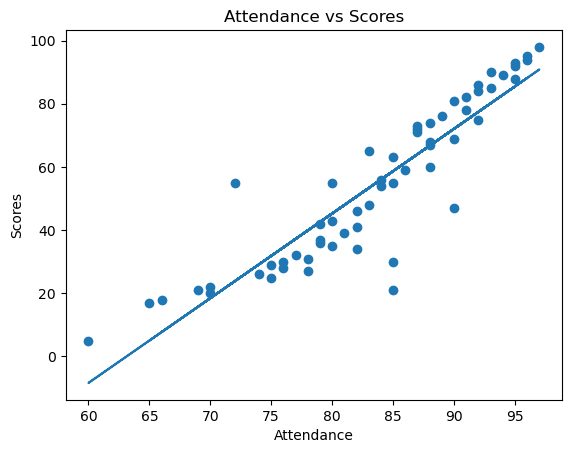

In [15]:
plt.scatter(X, y)          # actual data
plt.plot(X, y_pred)        # regression line

plt.xlabel("Attendance")
plt.ylabel("Scores")
plt.title("Attendance vs Scores")
plt.show()

In [16]:
residuals = y - y_pred

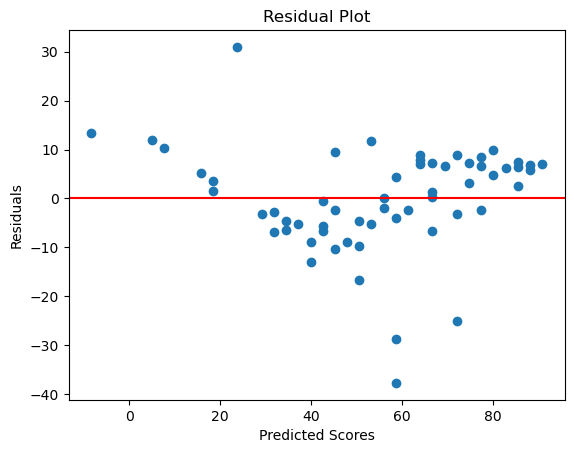

In [18]:
plt.scatter(y_pred, residuals)

# Red line (zero error)
plt.axhline(y=0, color='red')

plt.xlabel("Predicted Scores")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [19]:
import statsmodels.api as sm

X_sm = sm.add_constant(X)

model_sm = sm.OLS(y, X_sm).fit()

print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                 Scores   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     262.9
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           5.16e-23
Time:                        18:08:36   Log-Likelihood:                -223.15
No. Observations:                  59   AIC:                             450.3
Df Residuals:                      57   BIC:                             454.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -169.2996     13.891    -12.188      0.0

In [20]:
print("Slope:", model.coef_)
print("Intercept:", model.intercept_)

Slope: [2.68208123]
Intercept: -169.2995729049494
